In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
df = pd.read_csv('../data/cleaned/final.csv')
df.head()

,city,Area,Location,No. of Bedrooms,Resale,basic_amenities,intermediate_amenties,elite_amenities,Price,location_category
0,Bangalore,3340,JP Nagar Phase 1,4,0,0,0,1,30000000,Budget
1,Bangalore,1045,Dasarahalli on Tumkur Road,2,0,0,0,1,7888000,Budget
2,Bangalore,1179,Kannur on Thanisandra Main Road,2,0,0,0,0,4866000,Budget
3,Bangalore,1675,Doddanekundi,3,0,0,0,0,8358000,Budget
4,Bangalore,1670,Kengeri,3,0,0,0,1,6845000,Budget


In [3]:
df = df.drop('Location', axis=1)

In [4]:
df_dummies = pd.get_dummies(df, drop_first=True)

df_dummies.head()

,Area,No. of Bedrooms,Resale,basic_amenities,intermediate_amenties,elite_amenities,Price,city_Chennai,city_Delhi,city_Hyderabad,city_Kolkata,city_Mumbai,location_category_Luxury,location_category_Standard
0,3340,4,0,0,0,1,30000000,False,False,False,False,False,False,False
1,1045,2,0,0,0,1,7888000,False,False,False,False,False,False,False
2,1179,2,0,0,0,0,4866000,False,False,False,False,False,False,False
3,1675,3,0,0,0,0,8358000,False,False,False,False,False,False,False
4,1670,3,0,0,0,1,6845000,False,False,False,False,False,False,False


location_category_Luxury      0.575872
location_category_Standard    0.213680
Area                          0.147074
No. of Bedrooms               0.020314
city_Mumbai                   0.009584
Resale                        0.008547
city_Kolkata                  0.006329
city_Delhi                    0.005806
basic_amenities               0.005462
city_Chennai                  0.002360
elite_amenities               0.001991
intermediate_amenties         0.001799
city_Hyderabad                0.001181
dtype: float64


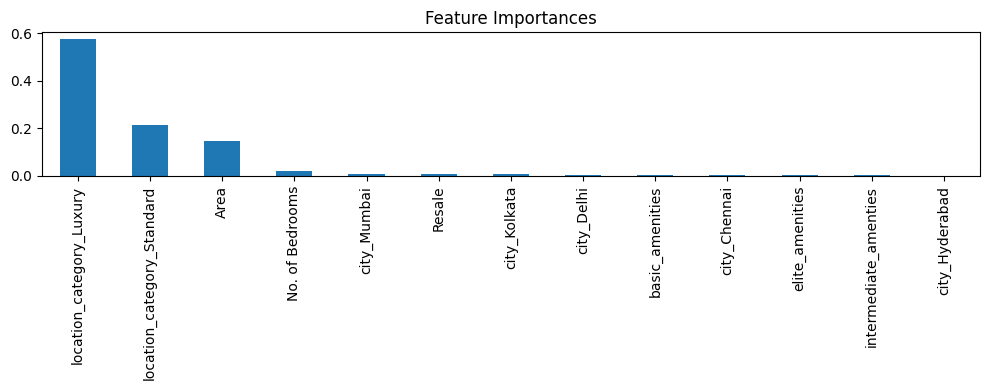

In [5]:
from sklearn.ensemble import RandomForestRegressor

# X and y
X = df_dummies.drop(columns=['Price'])  # drop target
y = df_dummies['Price']

# Fit model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Get feature importances
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

# Plot
importances.plot(kind='bar', figsize=(10, 4), title='Feature Importances')
plt.tight_layout()
plt.show()


In [6]:
df_dummies = df_dummies.drop('Resale', axis=1)

In [7]:
X = df_dummies.drop('Price',axis=1)
y = df_dummies['Price']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [10]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(X_train_sc, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_pred_lr = model_lr.predict(X_test_sc)

In [12]:
def evaluate(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}:")
    print(f"  R²   = {r2:.4f}")
    print(f"  MAE  = {mae:.2f}")
    print(f"  RMSE = {rmse:.2f}\n")


In [13]:
evaluate(y_test, y_pred_lr, "LinearRegression")

LinearRegression:
  R²   = 0.7486
  MAE  = 5882690.22
  RMSE = 12878996.29



In [17]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=200, random_state=42)
model_rf.fit(X_train_sc, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
y_pred_rf = model_rf.predict(X_test_sc)

In [19]:
evaluate(y_test, y_pred_rf, "RandomForestRegressor")

RandomForestRegressor:
  R²   = 0.7324
  MAE  = 5623885.19
  RMSE = 13286722.75



In [20]:
from sklearn.ensemble import GradientBoostingRegressor


model_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
model_gb.fit(X_train_sc, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [21]:
y_pred_gb = model_gb.predict(X_test_sc)

In [22]:
evaluate(y_test, y_pred_gb, "GradientBoostingRegressor")

GradientBoostingRegressor:
  R²   = 0.7406
  MAE  = 5482079.73
  RMSE = 13080777.87



In [23]:
y_train_pred = model_rf.predict(X_train_sc)
evaluate(y_train_pred, y_train, "RandomForestRegressor")

RandomForestRegressor:
  R²   = 0.9093
  MAE  = 3492807.14
  RMSE = 6565868.58



In [48]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_distributions = {
    'n_estimators': [100, 200, 500, 1000],
    'max_depth': [None, 10, 20, 50, 100],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['log2', 'sqrt'],
    'bootstrap': [True, False]
}


rf_random = RandomizedSearchCV(
    estimator=rf,  
    param_distributions=param_distributions,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    error_score='raise'
)

rf_random.fit(X_train_sc, y_train)

print('Best parameters from RandomizedSearch:', rf_random.best_params_)
print('Best score:', rf_random.best_score_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END bootstrap=True, max_depth=100, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END bootstrap=True, max_depth=100, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.5s
[CV] END bootstrap=True, max_depth=100, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.5s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   0.7s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   0.7s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   0.7s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=5

/Users/adityakumbhar/Developer/House_Price_Prediction/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   2.6s
[CV] END bootstrap=True, max_depth=50, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=1000; total time=  10.1s
[CV] END bootstrap=True, max_depth=50, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=1000; total time=  10.4s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   2.4s
[CV] END bootstrap=True, max_depth=50, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=1000; total time=  10.3s
[CV] END bootstrap=False, max_depth=50, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=1000; total time=  11.8s
[CV] END bootstrap=False, max_depth=50, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=1000; total time=  11.9s
[CV] END bootstrap=False, max_depth=50,

In [49]:
final_rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=10,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train_sc, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [50]:
y_pred_final = final_rf.predict(X_test_sc)

In [52]:
evaluate(y_pred_final, y_test, "RandomForestRegressor")

RandomForestRegressor:
  R²   = 0.6884
  MAE  = 5406488.74
  RMSE = 12289517.07



In [58]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],       # depth of individual trees
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

gbr = GradientBoostingRegressor(random_state=42)

rand_search = RandomizedSearchCV(
    gbr,
    param_distributions=params,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rand_search.fit(X_train_sc, y_train) 
print("Best params:", rand_search.best_params_)
print("Best score:", rand_search.best_score_)


Fitting 10 folds for each of 50 candidates, totalling 500 fits
[CV] END learning_rate=0.01, max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=300, subsample=1.0; total time=   1.5s
[CV] END learning_rate=0.01, max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=300, subsample=1.0; total time=   1.5s
[CV] END learning_rate=0.01, max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=300, subsample=1.0; total time=   1.5s
[CV] END learning_rate=0.01, max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=300, subsample=1.0; total time=   1.5s
[CV] END learning_rate=0.01, max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=300, subsample=1.0; total time=   1.5s
[CV] END learning_rate=0.01, max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=300, subsample=1.0; total time=   1.5s
[CV] EN

In [43]:
best_gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=600,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

best_gbr.fit(X_train_sc, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,600
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [44]:
y_pred_gbr = best_gbr.predict(X_test_sc)

In [45]:
evaluate(y_pred_gbr, y_test, "GradientBoostingRegressor")

GradientBoostingRegressor:
  R²   = 0.6814
  MAE  = 5381363.29
  RMSE = 13680392.40

